# HOMEWORK 12

In this homework you are going to inspect the GTSDB (German Traffic Sign Detection Benchmark) dataset. The dataset contains images of various classes of traffic signs used in Germany (and the whole EU). The objective of this homework is to go through the steps described below and to implement the necessary code.

At the end, as usual, there will be a couple of questions for you to answer. In addition, the last section of this homework is optional and, if you chose to do it, you'll earn extra point :-)

We will:
- load the training set,
- inspect random samples,
- build the per-class histogram,
- analyze image resolution distribution,
- analyze brightness distribution,
- compare average brightness across classes,
- draw conclusions.


In [2]:
import os
import cv2
import numpy as np
import pandas as pd

from collections import Counter
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [15, 10]


### Step 0

Go to the GTSRB dataset official site to learn more about the dataset.


### Step 1

Download the dataset and unzip it.


### Step 2

For this homework, we will work with the training set.  
Open `Train.csv`, inspect its contents, load the dataset, and plot random samples.


Number of training samples: 39209
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  


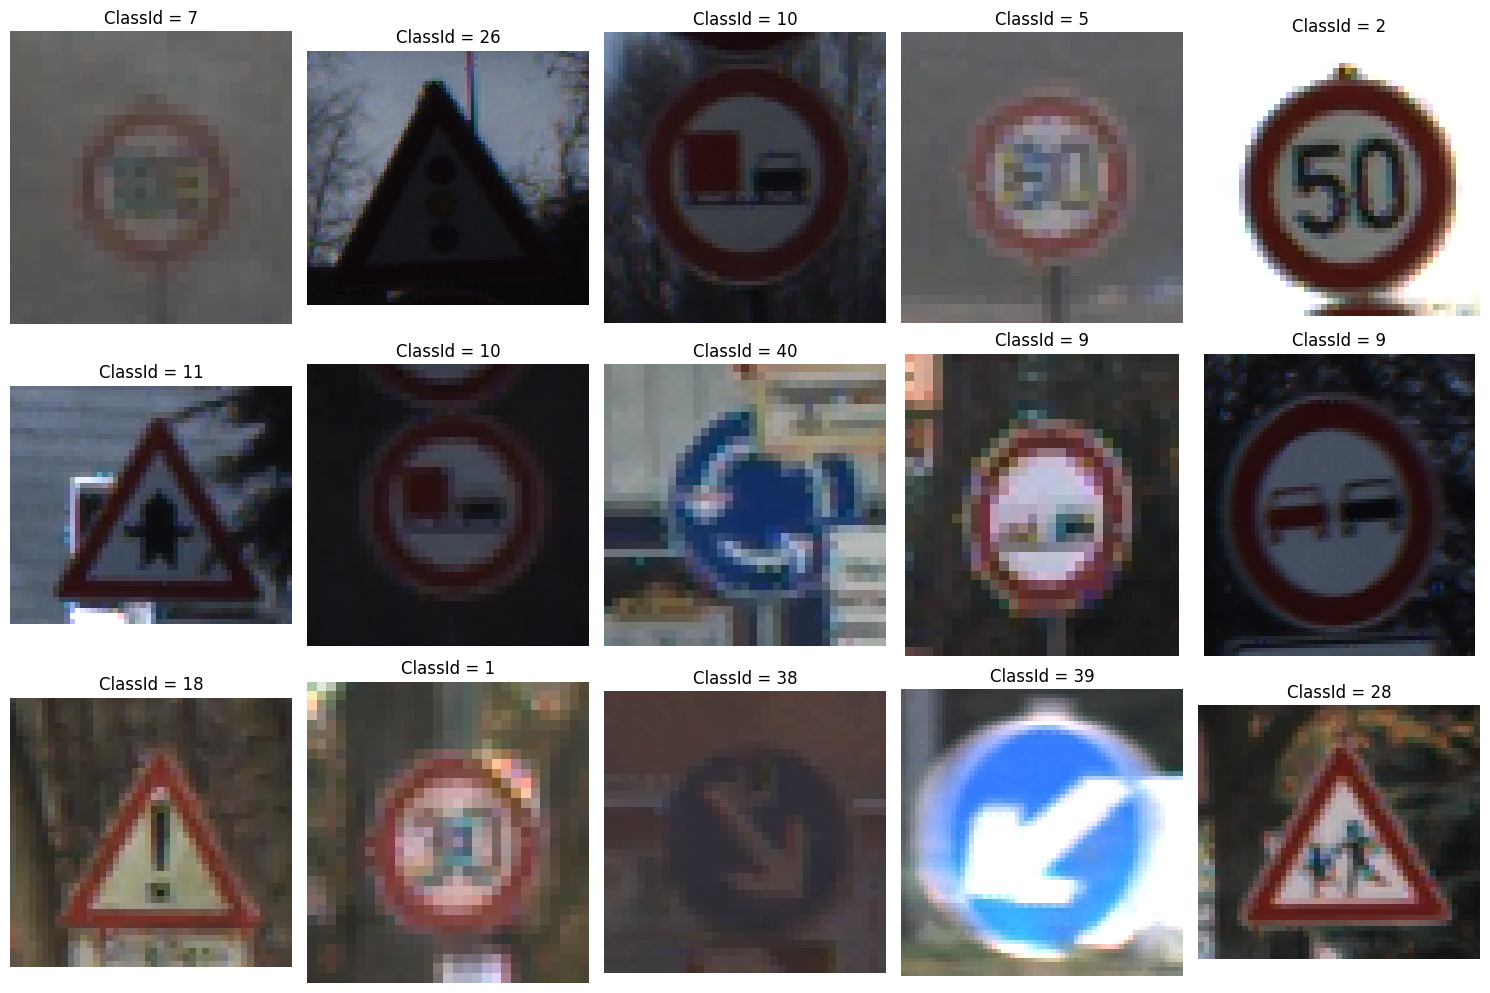

In [3]:
# Load the training labels
root = r'../GTSRB'  # Path to the dataset location
data = pd.read_csv(os.path.join(root, 'Train.csv'))

# Number of training samples
num_samples = len(data)
print('Number of training samples:', num_samples)
print(data.head())

# Show random data samples
plt.figure(figsize=(15, 10))

for ii in range(15):
    idx = np.random.randint(0, num_samples)

    img = cv2.imread(os.path.join(root, data.iloc[idx]['Path']))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 5, ii + 1)
    plt.imshow(img)
    plt.title(f"ClassId = {data.iloc[idx]['ClassId']}")
    plt.axis('off')

plt.tight_layout()
plt.show()


### Step 3

Inspect the dataset by computing and plotting the per-class histogram.


In [4]:
# Extract class identifiers
ids = data['ClassId'].values

print('Number of classes:', len(np.unique(ids)))
print('Class IDs:', np.unique(ids))


Number of classes: 43
Class IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]


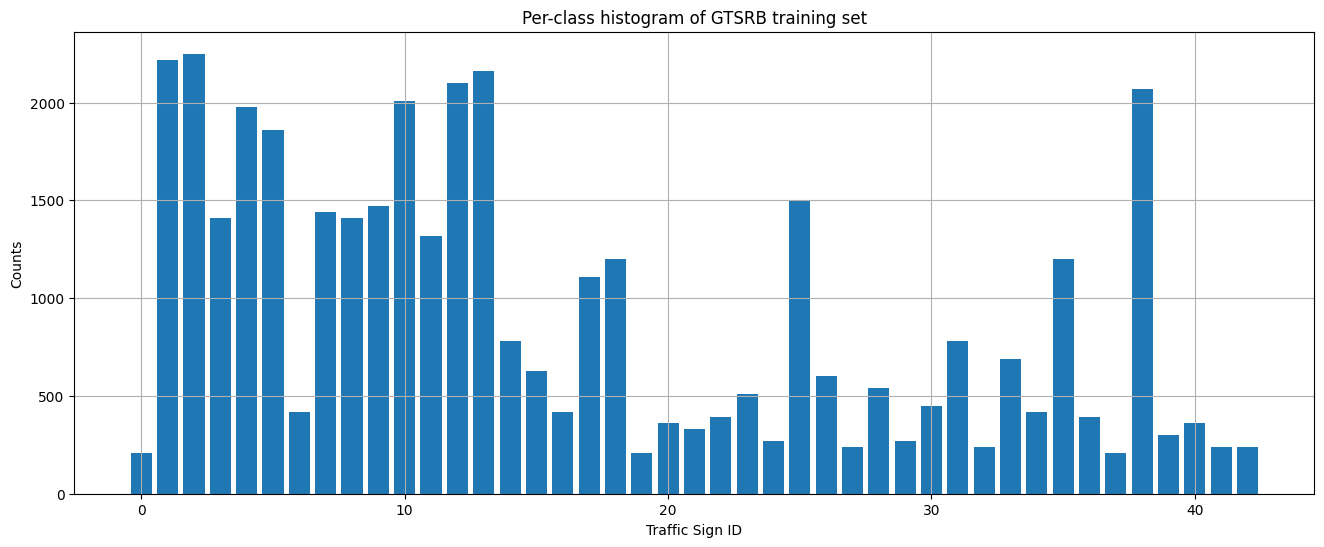

Top 5 most represented classes: [(np.int64(2), 2250), (np.int64(1), 2220), (np.int64(13), 2160), (np.int64(12), 2100), (np.int64(38), 2070)]
Top 5 least represented classes: [(np.int64(0), 210), (np.int64(19), 210), (np.int64(37), 210), (np.int64(27), 240), (np.int64(32), 240)]


In [5]:
# Compute the per-class histogram
hist = Counter(ids)

plt.figure(figsize=(16, 6))
plt.bar(hist.keys(), hist.values())
plt.grid(True)
plt.xlabel('Traffic Sign ID')
plt.ylabel('Counts')
plt.title('Per-class histogram of GTSRB training set')
plt.show()

print('Top 5 most represented classes:', hist.most_common(5))
print('Top 5 least represented classes:', sorted(hist.items(), key=lambda x: x[1])[:5])


### Step 4

Resolution distribution


In [6]:
widths = []
heights = []

for i in range(num_samples):
    img_path = os.path.join(root, data.iloc[i]['Path'])
    img = cv2.imread(img_path)

    h, w = img.shape[:2]
    heights.append(h)
    widths.append(w)

widths = np.array(widths)
heights = np.array(heights)

print('Width statistics:')
print('Min width:', widths.min())
print('Max width:', widths.max())
print('Mean width:', widths.mean())

print('\nHeight statistics:')
print('Min height:', heights.min())
print('Max height:', heights.max())
print('Mean height:', heights.mean())


Width statistics:
Min width: 25
Max width: 243
Mean width: 50.83587951745773

Height statistics:
Min height: 25
Max height: 225
Mean height: 50.328929582493814


### Step 5

Plot resolution distributions


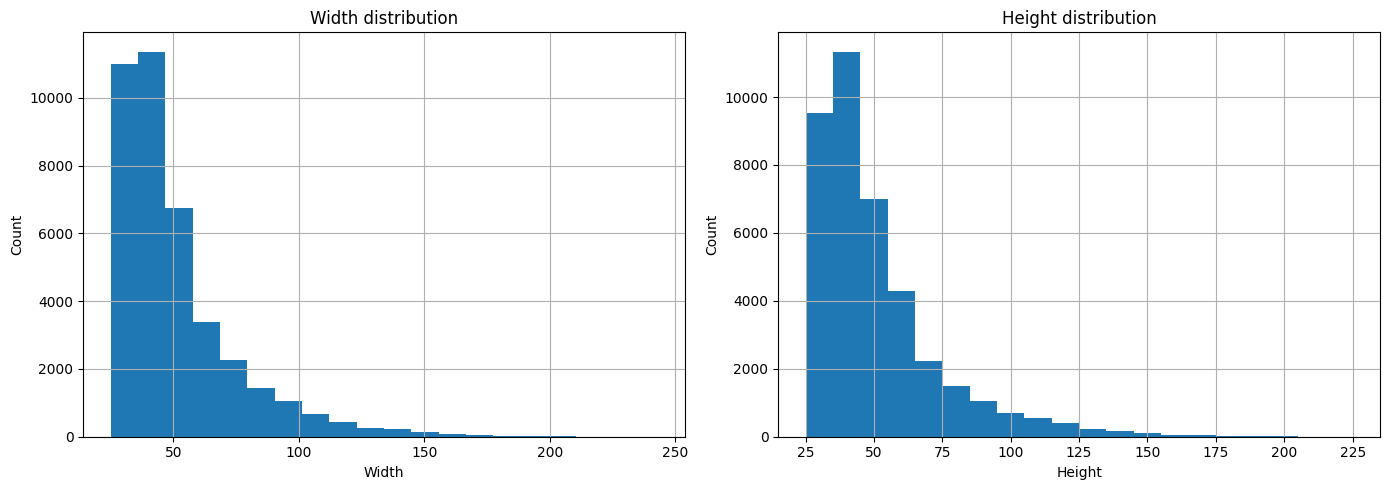

In [7]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(widths, bins=20)
plt.title('Width distribution')
plt.xlabel('Width')
plt.ylabel('Count')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(heights, bins=20)
plt.title('Height distribution')
plt.xlabel('Height')
plt.ylabel('Count')
plt.grid(True)

plt.tight_layout()
plt.show()


### Step 6

Analyze brightness distribution


In [11]:
brightness = []

for i in range(num_samples):
    img_path = os.path.join(root, data.iloc[i]['Path'])
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    brightness.append(np.mean(gray))

brightness = np.array(brightness)

print('Brightness statistics:')
print('Min brightness:', brightness.min())
print('Max brightness:', brightness.max())
print('Mean brightness:', brightness.mean())


Brightness statistics:
Min brightness: 6.202022777494475
Max brightness: 248.44000933706815
Mean brightness: 82.00611453570313


### Step 7

Plot overall brightness distribution


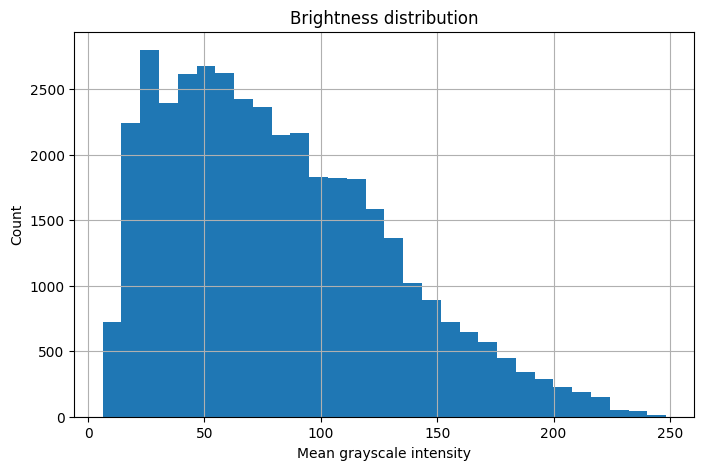

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(brightness, bins=30)
plt.title('Brightness distribution')
plt.xlabel('Mean grayscale intensity')
plt.ylabel('Count')
plt.grid(True)
plt.show()


### Step 8

Average brightness per class


In [10]:
brightness_per_class = {}

for class_id in np.unique(ids):
    class_brightness = brightness[ids == class_id]
    brightness_per_class[class_id] = class_brightness.mean()

print('Average brightness per class:')
for class_id, value in brightness_per_class.items():
    print(f'Class {class_id}: {value:.2f}')


Average brightness per class:
Class 0: 122.70
Class 1: 108.08
Class 2: 92.88
Class 3: 67.22
Class 4: 69.44
Class 5: 59.04
Class 6: 40.25
Class 7: 58.48
Class 8: 46.91
Class 9: 92.84
Class 10: 50.39
Class 11: 87.89
Class 12: 89.19
Class 13: 99.21
Class 14: 110.13
Class 15: 100.68
Class 16: 102.83
Class 17: 78.18
Class 18: 95.10
Class 19: 71.52
Class 20: 57.36
Class 21: 83.29
Class 22: 109.75
Class 23: 82.88
Class 24: 81.16
Class 25: 83.35
Class 26: 69.63
Class 27: 76.29
Class 28: 100.12
Class 29: 91.17
Class 30: 72.26
Class 31: 60.77
Class 32: 79.01
Class 33: 82.22
Class 34: 113.34
Class 35: 113.53
Class 36: 82.09
Class 37: 94.47
Class 38: 79.43
Class 39: 80.72
Class 40: 94.21
Class 41: 93.18
Class 42: 52.03


### Step 9

Plot brightness per class


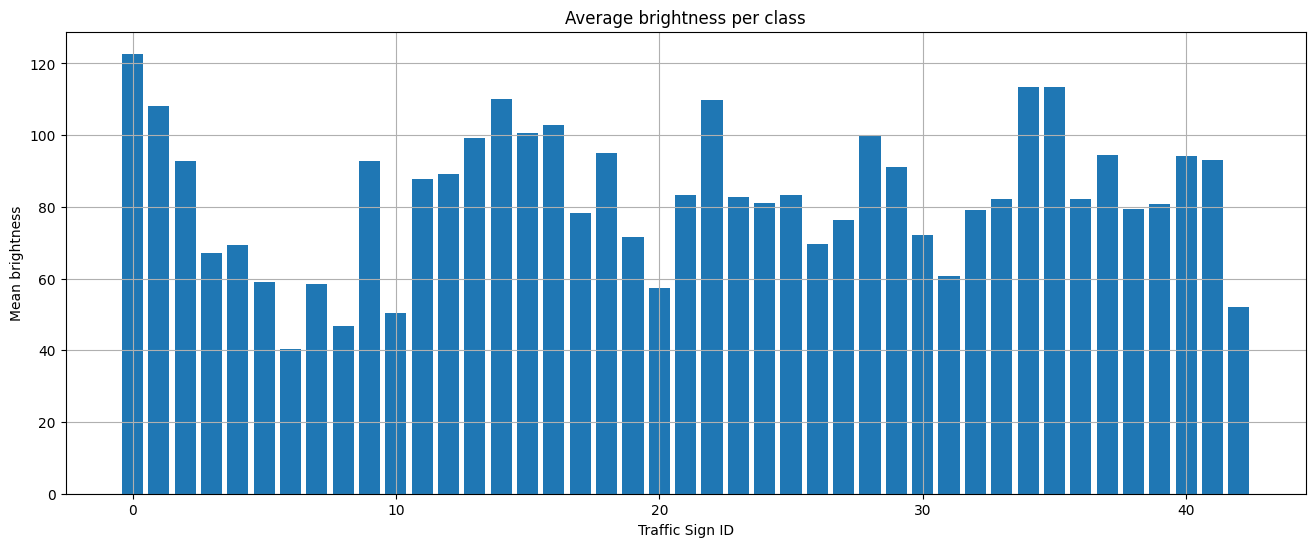

In [12]:
plt.figure(figsize=(16, 6))
plt.bar(brightness_per_class.keys(), brightness_per_class.values())
plt.title('Average brightness per class')
plt.xlabel('Traffic Sign ID')
plt.ylabel('Mean brightness')
plt.grid(True)
plt.show()


### Step 10

Find brightest and darkest classes


In [13]:
sorted_brightness = sorted(brightness_per_class.items(), key=lambda x: x[1])

print('5 darkest classes:')
for class_id, value in sorted_brightness[:5]:
    print(f'Class {class_id}: {value:.2f}')

print('\n5 brightest classes:')
for class_id, value in sorted_brightness[-5:]:
    print(f'Class {class_id}: {value:.2f}')


5 darkest classes:
Class 6: 40.25
Class 8: 46.91
Class 10: 50.39
Class 42: 52.03
Class 20: 57.36

5 brightest classes:
Class 22: 109.75
Class 14: 110.13
Class 34: 113.34
Class 35: 113.53
Class 0: 122.70


### Conclusion

The dataset contains images with different resolutions, so resizing is necessary before training.

The brightness distribution is also uneven, which means that the dataset was collected under different lighting conditions.

Some classes are brighter or darker on average, but this may depend not only on the class itself, but also on environmental conditions such as illumination, shadows, weather, and camera exposure.

Overall, the dataset is diverse and challenging for classification.


### Questions

**1. Do you consider the dataset to be balanced? If so, why? If not, why?**

No, the dataset is not balanced.  
The per-class histogram shows that the number of samples differs across classes. In a balanced dataset, each class should have approximately the same number of images. In GTSRB, some traffic sign classes contain many more samples than others, so the class distribution is uneven.

**2. Are there any classes that are significantly over-represented or under-represented?**

Yes, there are.  
Some classes are clearly over-represented, while others are under-represented. This can be seen directly from the histogram, where several classes have much taller bars and others have much shorter ones. Such imbalance may affect model training, because classes with fewer examples are usually harder for the model to learn.
